# Pipeline Corregido 
## Clasificación Multiclase de Incontinencia Urinaria

Este notebook es nuestra versión corregida del pipeline.
No modifica ningún archivo existente del equipo.

### ¿Qué corregimos respecto al pipeline original?

El pipeline original aplicaba SMOTE antes de guardar los datos,
lo que causaba que la validación cruzada se evaluara sobre datos
sintéticos y las métricas quedaran infladas artificialmente.

**Solución:** guardamos el train **sin SMOTE** para que cada modelo
pueda aplicarlo correctamente dentro de su validación cruzada.

| Archivo generado | Contenido | Uso |
|-----------------|-----------|-----|
| `X_train.csv` | Train escalado sin SMOTE | CV + entrenamiento |
| `y_train.csv` | Target del train | CV + entrenamiento |
| `X_test.csv` | Test escalado real | Evaluación definitiva |
| `y_test.csv` | Target del test | Evaluación definitiva |
| `scaler.pkl` | StandardScaler entrenado | Producción |


## 0. Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 1. Carga del dataset limpio

In [2]:
df = pd.read_csv("../data/processed/nhanes_clean.csv")

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Nulos: {df.isnull().sum().sum()}")
print(f"\nDistribución de clases:")
print(df['target_tipo_ui'].value_counts())

df.head()


Dataset cargado: 9,074 filas × 24 columnas
Nulos: 0

Distribución de clases:
target_tipo_ui
none      4857
mixed     1642
stress    1586
urge       989
Name: count, dtype: int64


,edad_anios,imc,dx_hipertension,dx_diabetes,dx_cancer,dx_artritis,fumadora_alguna_vez,actividad_fisica_vigorosa,nivel_pobreza_familiar,ui_frecuencia,...,ui_molestia_percibida,ui_impacto_actividades,target_tipo_ui,etnia_blanca,etnia_hisp_mex,etnia_hisp_otra,etnia_negra,etnia_otra,pais_mexico,pais_usa
0,29.0,37.8,0.0,0.0,0.0,0.0,0.0,1,3.0,1,...,1,1,none,0,0,0,0,1,1,0
1,21.0,30.2,0.0,0.0,0.0,0.0,0.0,1,3.0,1,...,2,1,none,0,0,1,0,0,1,0
2,44.0,39.1,0.0,0.0,0.0,0.0,0.0,0,2.4,4,...,2,2,stress,0,1,0,0,0,1,0
3,33.0,28.9,0.0,0.0,0.0,0.0,0.0,0,1.0,2,...,1,1,none,0,0,0,0,1,1,0
4,68.0,28.1,1.0,1.0,0.0,1.0,0.0,0,3.0,3,...,2,1,urge,0,0,0,1,0,0,1


## 2. Separación de features y target

### ¿Por qué eliminamos ui_esfuerzo_presente y ui_urgencia_presente?

Durante el EDA el análisis de Cramér's V detectó que estas variables
tienen V = 1.0 con el target. Forman parte del algoritmo clínico con
el que se construyó el target en NHANES, por lo que incluirlas sería
**data leakage** — el modelo haría trampa obteniendo métricas
artificialmente perfectas (~0.97) que no se reproducen en producción.


In [3]:
X = df.drop(columns=['target_tipo_ui'])
y = df['target_tipo_ui']

# Eliminar variables leaky
cols_leaky = ['ui_esfuerzo_presente', 'ui_urgencia_presente']
X = X.drop(columns=cols_leaky, errors='ignore')

print(f"Variables leaky eliminadas: {cols_leaky}")
print(f"Features finales: {X.shape[1]} columnas")
print(f"\nColumnas:")
print(X.columns.tolist())


Variables leaky eliminadas: ['ui_esfuerzo_presente', 'ui_urgencia_presente']
Features finales: 21 columnas

Columnas:
['edad_anios', 'imc', 'dx_hipertension', 'dx_diabetes', 'dx_cancer', 'dx_artritis', 'fumadora_alguna_vez', 'actividad_fisica_vigorosa', 'nivel_pobreza_familiar', 'ui_frecuencia', 'ui_cantidad', 'ui_otro_tipo_presente', 'ui_molestia_percibida', 'ui_impacto_actividades', 'etnia_blanca', 'etnia_hisp_mex', 'etnia_hisp_otra', 'etnia_negra', 'etnia_otra', 'pais_mexico', 'pais_usa']


## 3. Split estratificado 80/20

Mantenemos el mismo split que el pipeline original (80/20)
para que los resultados sean comparables con los otros modelos del equipo.

> ⚠️ El SMOTE **no se aplica aquí**.
> Cada modelo lo aplicará dentro de su validación cruzada.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Proporción de clases en TRAIN:")
print((y_train.value_counts(normalize=True) * 100).round(1))

print("\nProporción de clases en TEST:")
print((y_test.value_counts(normalize=True) * 100).round(1))

print(f"\nTamaño train: {X_train.shape[0]:,} filas")
print(f"Tamaño test:  {X_test.shape[0]:,} filas")


Proporción de clases en TRAIN:
target_tipo_ui
none      53.5
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Proporción de clases en TEST:
target_tipo_ui
none      53.6
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Tamaño train: 7,259 filas
Tamaño test:  1,815 filas


## 4. Escalado con StandardScaler

> ⚠️ El scaler se entrena (fit) **solo con train** y se aplica
> (transform) al test. Nunca al revés — data leakage prevention.


In [5]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print("✅ Escalado completado")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")


✅ Escalado completado
X_train_scaled: (7259, 21)
X_test_scaled:  (1815, 21)


## 5. Verificación de calidad

Comprobamos que los datos están listos antes de guardar.


VERIFICACIÓN DE CALIDAD

Nulos en X_train: 0
Nulos en X_test:  0

Distribución en train:
target_tipo_ui
none      53.5
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Distribución en test:
target_tipo_ui
none      53.6
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64


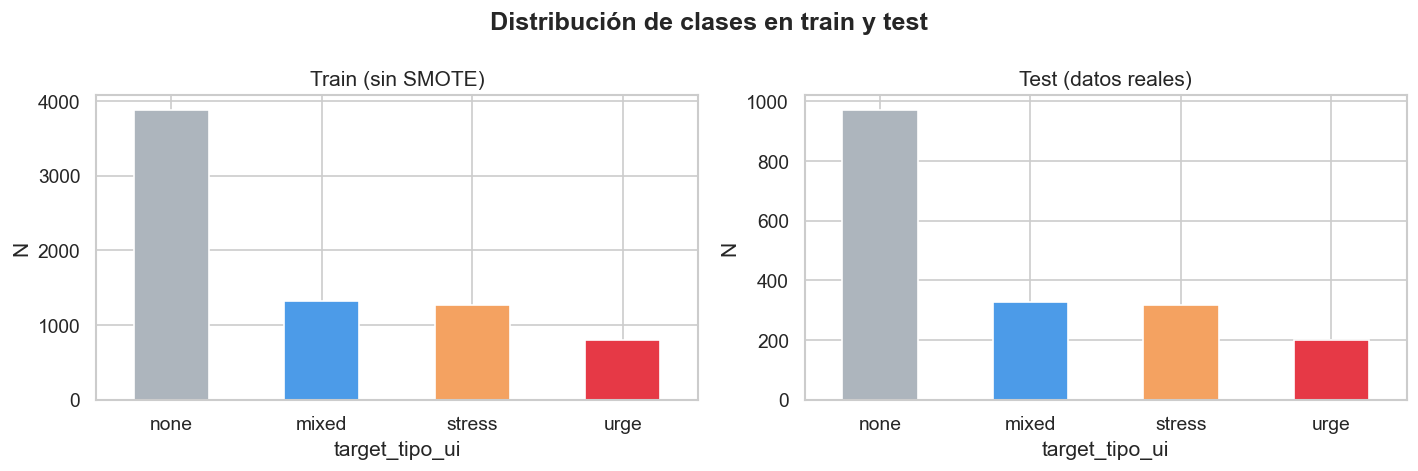


✅ Datos listos para guardar


In [6]:
print("=" * 50)
print("VERIFICACIÓN DE CALIDAD")
print("=" * 50)

print(f"\nNulos en X_train: {X_train_scaled.isnull().sum().sum()}")
print(f"Nulos en X_test:  {X_test_scaled.isnull().sum().sum()}")

print(f"\nDistribución en train:")
print((y_train.value_counts(normalize=True) * 100).round(1))

print(f"\nDistribución en test:")
print((y_test.value_counts(normalize=True) * 100).round(1))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribución de clases en train y test', fontweight='bold')

colores = ['#ADB5BD', '#4C9BE8', '#F4A261', '#E63946']

y_train.value_counts().plot(kind='bar', ax=axes[0], color=colores,
    edgecolor='white', title='Train (sin SMOTE)')
axes[0].set_ylabel('N'); axes[0].tick_params(axis='x', rotation=0)

y_test.value_counts().plot(kind='bar', ax=axes[1], color=colores,
    edgecolor='white', title='Test (datos reales)')
axes[1].set_ylabel('N'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n✅ Datos listos para guardar")


## 6. Guardado de archivos

In [8]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# Train sin SMOTE
X_train_scaled.to_csv("../data/processed/X_train_clean.csv", index=False)
y_train.to_csv("../data/processed/y_train_clean.csv", index=False)

# Test con datos reales
X_test_scaled.to_csv("../data/processed/X_test_clean.csv", index=False)
y_test.to_csv("../data/processed/y_test_clean.csv", index=False)

# Scaler
joblib.dump(scaler, "../models/scaler_clean.pkl")

print("✅ Archivos guardados:")
print(f"  X_train_clean.csv → {X_train_scaled.shape[0]:,} filas (sin SMOTE)")
print(f"  y_train_clean.csv → {len(y_train):,} filas")
print(f"  X_test_clean.csv  → {X_test_scaled.shape[0]:,} filas (datos reales)")
print(f"  y_test_clean.csv  → {len(y_test):,} filas")
print(f"  scaler.pkl")


✅ Archivos guardados:
  X_train_clean.csv → 7,259 filas (sin SMOTE)
  y_train_clean.csv → 7,259 filas
  X_test_clean.csv  → 1,815 filas (datos reales)
  y_test_clean.csv  → 1,815 filas
  scaler.pkl


## Resumen del pipeline

| Paso | Acción | Resultado |
|------|--------|-----------|
| 1 | Carga dataset limpio | 9,074 filas × 24 columnas |
| 2 | Eliminación variables leaky | ui_esfuerzo_presente, ui_urgencia_presente → 22 columnas |
| 3 | Split estratificado 80/20 | Train: 7,259 filas · Test: 1,815 filas |
| 4 | StandardScaler | fit en train, transform en test |
| 5 | Guardado sin SMOTE | SMOTE se aplica dentro de cada modelo |

**Archivos generados en `data/processed/`:**
- `X_train_clean.csv` → 7,259 filas × 21 features (sin SMOTE)
- `y_train_clean.csv` → 7,259 filas
- `X_test_clean.csv` → 1,815 filas × 21 features (datos reales)
- `y_test_clean.csv` → 1,815 filas
- `scaler.pkl` → StandardScaler entrenado con train

## 📌 Instrucciones para todos los notebooks de modelado

Cada modelo del equipo debe seguir este patrón:

**1. Cargar los archivos de este pipeline:**
```python
X_train = pd.read_csv("../data/processed/X_train_clean.csv")
y_train = pd.read_csv("../data/processed/y_train_clean.csv").squeeze()
X_test  = pd.read_csv("../data/processed/X_test_clean.csv")
y_test  = pd.read_csv("../data/processed/y_test_clean.csv").squeeze()
```

**2. Aplicar SMOTE dentro de la validación cruzada usando ImbPipeline:**
```python
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('modelo', TuClasificador(...))
])
scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='f1_macro')
```

**3. Aplicar SMOTE manualmente para el entrenamiento final:**
```python
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
modelo.fit(X_train_bal, y_train_bal)
```

**4. Evaluar siempre con X_test_clean.csv — nunca aplicar SMOTE al test.**